<a href="https://colab.research.google.com/github/hyaksart/yolov11-traffic-sign-detection-izzul/blob/main/Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

# Lokasi file di Drive (sesuai screenshot kamu)
path_zip = "/content/drive/MyDrive/Dataset_Final_YOLO.zip"
path_tujuan = "/content/dataset_skripsi"

if os.path.exists(path_zip):
    print("-> Sedang meng-copy dan unzip dataset... (Tunggu sebentar)")
    !unzip -q "$path_zip" -d "$path_tujuan"
    print("-> SUKSES! Dataset siap digunakan.")
else:
    print("[ERROR] File ZIP tidak ditemukan! Cek apakah nama filenya benar 'Dataset_Final_YOLO.zip'")

-> Sedang meng-copy dan unzip dataset... (Tunggu sebentar)
-> SUKSES! Dataset siap digunakan.


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.4 MB/s eta 0:00:00


In [ ]:
# Membuat file konfigurasi otomatis
yaml_content = """
path: /content/dataset_skripsi/Dataset_Final_YOLO
train: train/images
val: val/images
test: test/images

nc: 3  # Jumlah Kelas
names: ['Belok Kiri', 'Belok Kanan', 'Stop'] # <--- CEK URUTAN INI (Sesuaikan dengan classes.txt mu)
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("-> File data.yaml berhasil dibuat.")

-> File data.yaml berhasil dibuat.


In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("yolo11n.pt")

# Training Langsung Save ke Drive
print("-> Training dimulai. Hasil akan otomatis masuk Google Drive.")

results = model.train(
    data="data.yaml",
    epochs=50,
    patience=20,
    imgsz=640,
    batch=16,

    # === BAGIAN INI YANG BIKIN AMAN ===
    # Hasilnya langsung masuk ke Drive > MyDrive > Skripsi_Izzul
    project="/content/drive/MyDrive/Skripsi_Izzul",
    name="Model_Final_Fix",
    # ==================================

    plots=True,
    optimizer='AdamW',

    # === SETTINGAN WAJIB BIAR KIRI GAK JADI KANAN ===
    fliplr=0.0,
    degrees=10.0,
    mosaic=1.0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
-> Training dimulai. Hasil akan otomatis masuk Google Drive.
Ultralytics 8.4.9 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.

In [ ]:
from google.colab import drive
import pandas as pd
import os

# 1. CONNECT GOOGLE DRIVE
print("Sedang menghubungkan ke Google Drive...")
drive.mount('/content/drive')

# 2. LOAD FILE CSV
# Lokasi file sesuai dengan folder kamu yang terakhir: 'Colab Notebooks'
file_path = '/content/drive/MyDrive/Colab Notebooks/results.csv'

if os.path.exists(file_path):
    # Baca data
    data = pd.read_csv(file_path)

    # Bersihkan nama kolom (hilangkan spasi yang sering bikin error)
    data.columns = data.columns.str.strip()

    # 3. CARI NILAI TERTINGGI (BEST RESULT)
    # Kita cari baris dimana mAP50 paling tinggi (ini dianggap model terbaik/best.pt)
    best_epoch_idx = data['metrics/mAP50(B)'].idxmax()
    best_epoch_data = data.loc[best_epoch_idx]

    print("\n" + "="*40)
    print("   HASIL PERFORMA TERBAIK (UNTUK SKRIPSI)")
    print("="*40)
    print(f"Dicapai pada Epoch ke : {best_epoch_data['epoch']:.0f}")
    print("-" * 40)

    # Ambil data dan ubah jadi persen
    precision = best_epoch_data['metrics/precision(B)'] * 100
    recall    = best_epoch_data['metrics/recall(B)'] * 100
    map50     = best_epoch_data['metrics/mAP50(B)'] * 100
    map5095   = best_epoch_data['metrics/mAP50-95(B)'] * 100

    print(f"✅ Precision  : {precision:.2f}%")
    print(f"✅ Recall     : {recall:.2f}%")
    print(f"✅ mAP@0.5    : {map50:.2f}%")
    print(f"✅ mAP@0.5-95 : {map5095:.2f}%")
    print("="*40)

    # CONTOH KALIMAT UNTUK ABSTRAK
    print("\n📝 CONTOH KALIMAT UNTUK ABSTRAK/KESIMPULAN:")
    print(f'"Hasil pelatihan menunjukkan nilai Precision sebesar {precision:.1f}%, '
          f'Recall sebesar {recall:.1f}%, serta mAP@0.5 mencapai {map50:.1f}%."')

else:
    print(f"❌ File tidak ditemukan di: {file_path}")
    print("Cek lagi apakah file results.csv benar-benar ada di folder 'Colab Notebooks'.")

Sedang menghubungkan ke Google Drive...
Mounted at /content/drive

   HASIL PERFORMA TERBAIK (UNTUK SKRIPSI)
Dicapai pada Epoch ke : 43
----------------------------------------
✅ Precision  : 99.75%
✅ Recall     : 98.28%
✅ mAP@0.5    : 99.43%
✅ mAP@0.5-95 : 86.68%

📝 CONTOH KALIMAT UNTUK ABSTRAK/KESIMPULAN:
"Hasil pelatihan menunjukkan nilai Precision sebesar 99.7%, Recall sebesar 98.3%, serta mAP@0.5 mencapai 99.4%."


🔍 SEDANG MENCARI FILE HASIL TRAINING...
❌ GAWAT: File results.csv tidak ditemukan! Apakah training sudah selesai?
✅ FILE DITEMUKAN DI: /content/drive/MyDrive/Skripsi_Izzul/Model_Final_Fix/results.csv

📊 MEMBUAT GRAFIK LOSS & METRIK...


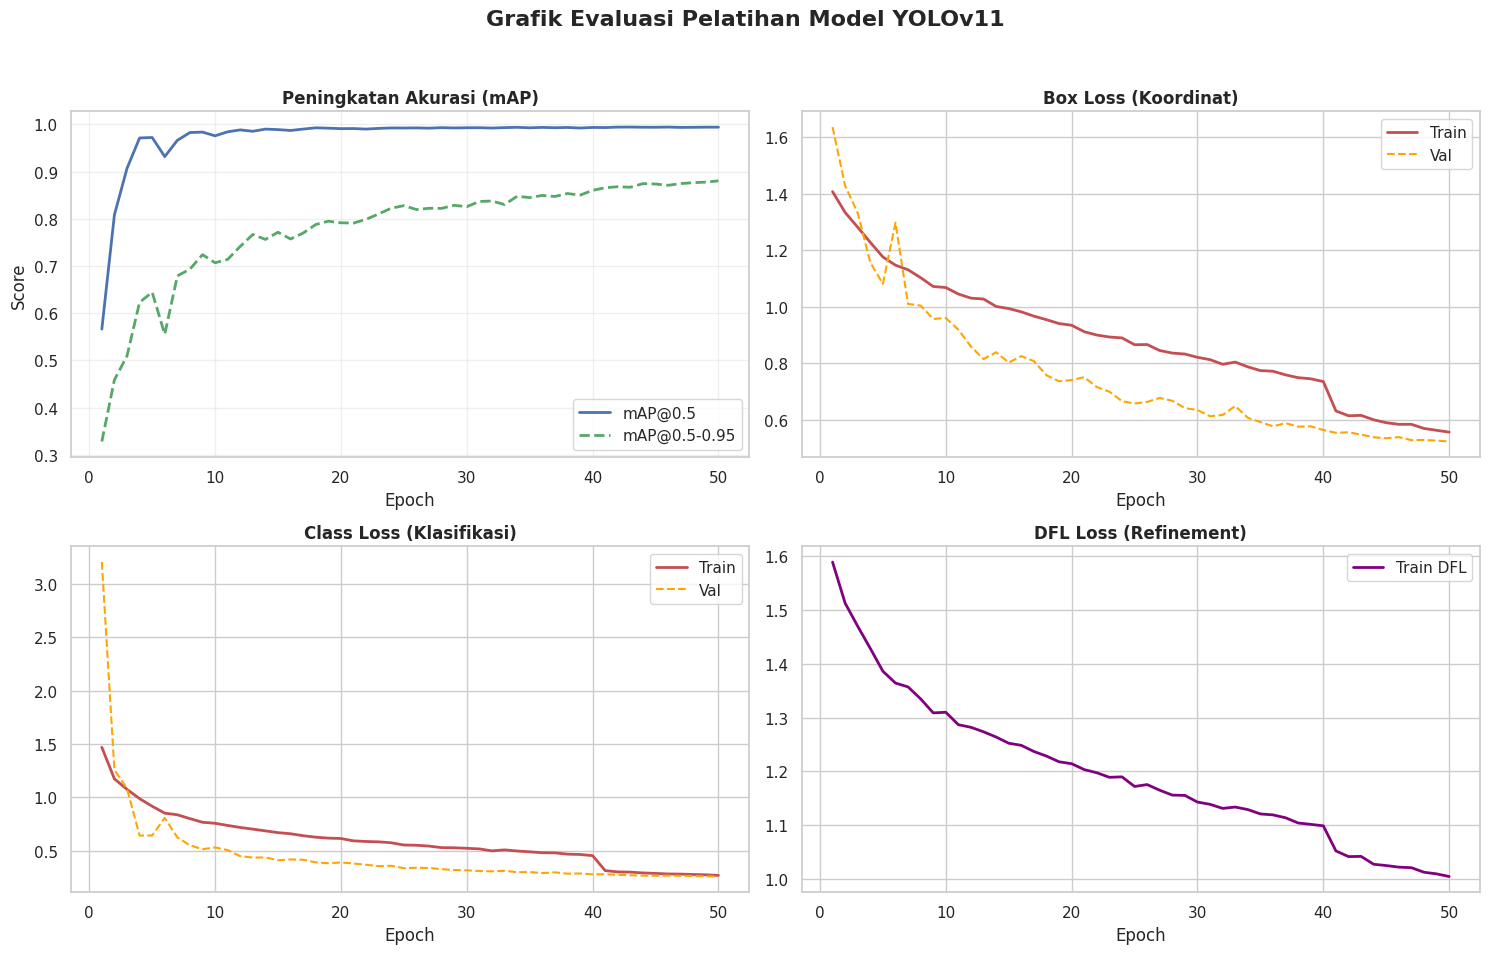

✅ Grafik tersimpan sebagai: grafik_evaluasi_lengkap.png


In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from IPython.display import display, Markdown

# ==========================================
# 1. PENCARI FILE OTOMATIS (AUTO-DETECT)
# ==========================================
print("🔍 SEDANG MENCARI FILE HASIL TRAINING...")

# Mencari file results.csv di seluruh folder /content/runs/
search_results = glob.glob('/content/runs/**/results.csv', recursive=True)
search_weights = glob.glob('/content/runs/**/best.pt', recursive=True)

if not search_results:
    print("❌ GAWAT: File results.csv tidak ditemukan! Apakah training sudah selesai?")
    # Fallback: Coba cari di folder drive jika user menyimpannya disana
    search_results = glob.glob('/content/drive/MyDrive/**/results.csv', recursive=True)

if search_results:
    # Ambil file terbaru
    csv_file = max(search_results, key=os.path.getmtime)
    folder_hasil = os.path.dirname(csv_file)
    print(f"✅ FILE DITEMUKAN DI: {csv_file}")

    # Baca Data
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip() # Bersihkan nama kolom

    # Setup Style Grafik
    sns.set(style="whitegrid")
    plt.rcParams.update({'font.size': 10})

    # ==========================================
    # 2. GENERATE GRAFIK LOSS & mAP (High Quality)
    # ==========================================
    print("\n📊 MEMBUAT GRAFIK LOSS & METRIK...")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Grafik Evaluasi Pelatihan Model YOLOv11', fontsize=16, fontweight='bold')

    # A. Grafik mAP (Akurasi)
    axes[0, 0].plot(df['epoch'], df['metrics/mAP50(B)'], 'b-', linewidth=2, label='mAP@0.5')
    axes[0, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], 'g--', linewidth=2, label='mAP@0.5-0.95')
    axes[0, 0].set_title('Peningkatan Akurasi (mAP)', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # B. Box Loss
    axes[0, 1].plot(df['epoch'], df['train/box_loss'], 'r-', linewidth=2, label='Train')
    axes[0, 1].plot(df['epoch'], df['val/box_loss'], 'orange', linestyle='--', label='Val')
    axes[0, 1].set_title('Box Loss (Koordinat)', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()

    # C. Class Loss
    axes[1, 0].plot(df['epoch'], df['train/cls_loss'], 'r-', linewidth=2, label='Train')
    axes[1, 0].plot(df['epoch'], df['val/cls_loss'], 'orange', linestyle='--', label='Val')
    axes[1, 0].set_title('Class Loss (Klasifikasi)', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()

    # D. DFL Loss
    axes[1, 1].plot(df['epoch'], df['train/dfl_loss'], 'purple', linewidth=2, label='Train DFL')
    axes[1, 1].set_title('DFL Loss (Refinement)', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('grafik_evaluasi_lengkap.png', dpi=300)
    plt.show()
    print("✅ Grafik tersimpan sebagai: grafik_evaluasi_lengkap.png")

    # ==========================================
    # 3. GRAFIK KESEIMBANGAN

Sedang menghubungkan ke Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ KETEMU! File ditemukan di: /content/drive/MyDrive/Colab Notebooks/results.csv


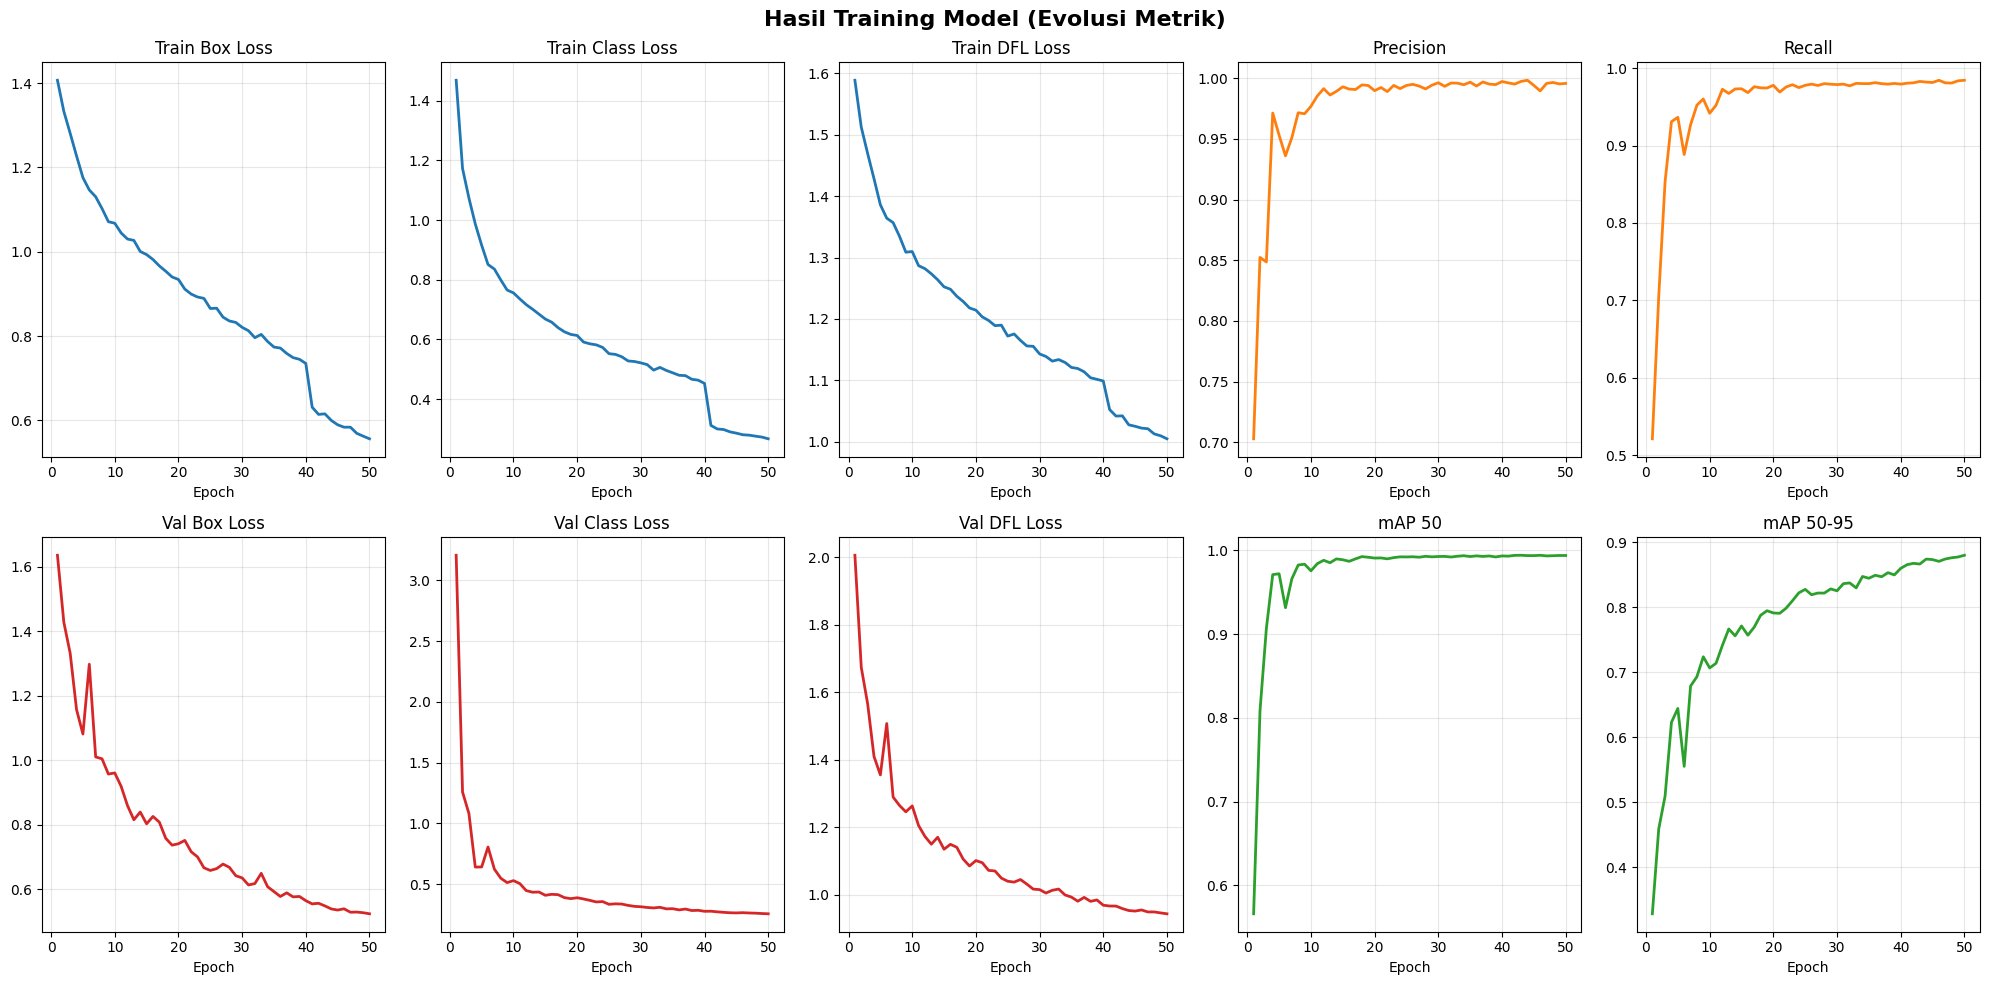

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. CONNECT GOOGLE DRIVE
print("Sedang menghubungkan ke Google Drive...")
drive.mount('/content/drive')

# 2. LOKASI FILE (Sudah saya perbaiki sesuai fotomu)
# Filenya ada di dalam folder 'Colab Notebooks'
file_path = '/content/drive/MyDrive/Colab Notebooks/results.csv'

# Cek apakah file benar-benar ada
if os.path.exists(file_path):
    print(f"✅ KETEMU! File ditemukan di: {file_path}")

    # Baca data
    data = pd.read_csv(file_path)
    data.columns = data.columns.str.strip()

    # 3. BUAT GRAFIK
    fig, axs = plt.subplots(2, 5, figsize=(20, 10))
    fig.suptitle('Hasil Training Model (Evolusi Metrik)', fontsize=16, fontweight='bold')

    plots_config = [
        ('train/box_loss', 'Train Box Loss', 0, 0, '#1f77b4'),
        ('train/cls_loss', 'Train Class Loss', 0, 1, '#1f77b4'),
        ('train/dfl_loss', 'Train DFL Loss', 0, 2, '#1f77b4'),
        ('metrics/precision(B)', 'Precision', 0, 3, '#ff7f0e'),
        ('metrics/recall(B)', 'Recall', 0, 4, '#ff7f0e'),
        ('val/box_loss', 'Val Box Loss', 1, 0, '#d62728'),
        ('val/cls_loss', 'Val Class Loss', 1, 1, '#d62728'),
        ('val/dfl_loss', 'Val DFL Loss', 1, 2, '#d62728'),
        ('metrics/mAP50(B)', 'mAP 50', 1, 3, '#2ca02c'),
        ('metrics/mAP50-95(B)', 'mAP 50-95', 1, 4, '#2ca02c'),
    ]

    for col_name, title, row, col, color in plots_config:
        ax = axs[row, col]
        if col_name in data.columns:
            ax.plot(data['epoch'], data[col_name], label=title, color=color, linewidth=2)
            ax.set_title(title)
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print(f"\n❌ MASIH TIDAK KETEMU di: {file_path}")
    print("Coba pindahkan file 'results.csv' ke halaman depan Google Drive (jangan di dalam folder apapun) lalu coba lagi.")